# LoRA Re-implementation
Re-implementing Table 2 (RoBERTa-base on GLUE)

Using the authors' own `loralib` package directly (not HuggingFace PEFT).

In [ ]:
# Install the authors' own loralib package + dependencies
!pip install -q loralib transformers datasets scikit-learn

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import loralib as lora
from sklearn.metrics import accuracy_score
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from transformers.models.roberta.modeling_roberta import RobertaSelfAttention
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 1. LoRA Layer Injection

The paper's key idea: for a frozen weight matrix $W_0 \in \mathbb{R}^{d \times k}$, the adapted forward pass becomes:

$$h = W_0 x + \Delta W x = W_0 x + BAx$$

where $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$, and $r \ll \min(d, k)$.


In [ ]:
def apply_lora(model, r=8, lora_alpha=8, lora_dropout=0.0, target_modules=("query", "value")):
    """
    Replace specified attention projections with lora.Linear in every self-attention layer.
    Copies pretrained weights over so we don't lose them.
    Freezes all non-LoRA parameters via lora.mark_only_lora_as_trainable.
    """
    for module in model.modules():
        if not isinstance(module, RobertaSelfAttention):
            continue

        hidden   = module.query.in_features
        head_dim = module.query.out_features

        if "query" in target_modules:
            new_q = lora.Linear(hidden, head_dim, r=r, lora_alpha=lora_alpha, lora_dropout=lora_dropout)
            new_q.weight.data = module.query.weight.data.clone()  # copy pretrained W
            new_q.bias.data   = module.query.bias.data.clone()
            module.query = new_q

        if "value" in target_modules:
            new_v = lora.Linear(hidden, head_dim, r=r, lora_alpha=lora_alpha, lora_dropout=lora_dropout)
            new_v.weight.data = module.value.weight.data.clone()
            new_v.bias.data   = module.value.bias.data.clone()
            module.value = new_v

    # Freeze everything except parameters named "lora_*"
    lora.mark_only_lora_as_trainable(model)
    return model


def count_params(model):
    """Return (trainable, total) parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

## 2. Load and Tokenize Datasets

In [ ]:
TOKENIZER = RobertaTokenizerFast.from_pretrained("roberta-base")

def load_glue(task, max_length=128):
    """Download a GLUE task, tokenize, and return as a DatasetDict of tensors."""
    dataset = load_dataset("glue", task)

    if task == "sst2":
        tokenize     = lambda ex: TOKENIZER(ex["sentence"], truncation=True, padding="max_length", max_length=max_length)
        drop_columns = ["sentence", "idx"]
    elif task == "qnli":
        # QNLI encodes a (question, sentence) pair
        tokenize     = lambda ex: TOKENIZER(ex["question"], ex["sentence"], truncation=True, padding="max_length", max_length=max_length)
        drop_columns = ["question", "sentence", "idx"]

    dataset = dataset.map(tokenize, batched=True)
    dataset = dataset.rename_column("label", "labels")
    dataset = dataset.remove_columns(drop_columns)
    dataset.set_format("torch")
    return dataset


sst2 = load_glue("sst2")
qnli = load_glue("qnli")

print("SST-2:", sst2)
print("QNLI: ", qnli)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/104743 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

SST-2: DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1821
    })
})
QNLI:  DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5463
    })
})


## 3. Training Helper

Default to 10 epochs in train_and_eval() function but the paper used 60.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


def train_and_eval(model, train_data, eval_data, output_dir,
                   lr=5e-4, epochs=10, batch_size=16):
    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=64,
        num_train_epochs=epochs,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        fp16=torch.cuda.is_available(),
        weight_decay=0.01,
        warmup_ratio=0.06,
        lr_scheduler_type="linear",
        logging_steps=200,
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_data,
        eval_dataset=eval_data,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    final_metrics = trainer.evaluate()
    logs = trainer.state.log_history

    train_loss = []
    val_loss = []
    val_acc = []

    for log in logs:
        if "loss" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])

        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])

        if "eval_accuracy" in log:
            val_acc.append(log["eval_accuracy"])

    return {
        "final_metrics": final_metrics,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }

In [ ]:
lora_results = train_and_eval(
    model_lora,
    sst2["train"],
    sst2["validation"],
    output_dir="./out/lora_sst2",
    lr=5e-4,
    epochs=EPOCHS
)

ft_results = train_and_eval(
    model_ft,
    sst2["train"],
    sst2["validation"],
    output_dir="./out/ft_sst2",
    lr=2e-5,
    epochs=EPOCHS
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.421732,0.532401,0.735092
2,0.432136,0.547710,0.755734
3,0.413129,0.524757,0.780963
4,0.389084,0.551858,0.764908
5,0.367033,0.536197,0.770642
6,0.346769,0.589127,0.776376
7,0.330265,0.556822,0.782110
8,0.309044,0.587223,0.784404
9,0.296116,0.599230,0.785550
10,0.285007,0.616519,0.782110


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.208644,0.654032,0.774083
2,0.215730,0.728873,0.802752
3,0.190252,0.889016,0.792431
4,0.164777,0.884864,0.784404
5,0.147573,1.007578,0.797018
6,0.130749,1.062899,0.794725
7,0.111715,1.154452,0.791284
8,0.095414,1.226118,0.795872
9,0.085112,1.241487,0.798165
10,0.080344,1.339301,0.795872


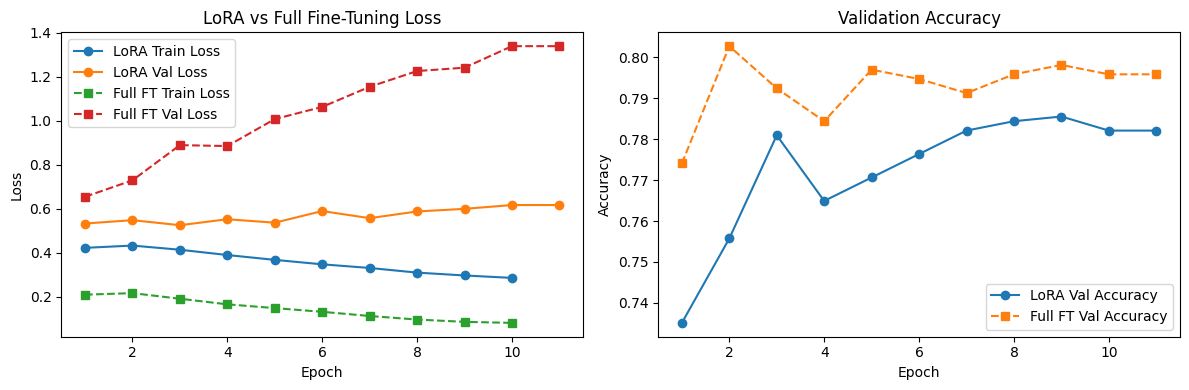

In [ ]:
x = [i + 1 for i in range(EPOCHS)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ----- Create correct x-axes -----
x_lora_train = range(1, len(lora_results["train_loss"]) + 1)
x_lora_val   = range(1, len(lora_results["val_loss"]) + 1)

x_ft_train = range(1, len(ft_results["train_loss"]) + 1)
x_ft_val   = range(1, len(ft_results["val_loss"]) + 1)

# ---------------- Loss Plot ----------------
ax1.plot(x_lora_train,
         lora_results["train_loss"],
         marker='o',
         label='LoRA Train Loss')

ax1.plot(x_lora_val,
         lora_results["val_loss"],
         marker='o',
         label='LoRA Val Loss')

ax1.plot(x_ft_train,
         ft_results["train_loss"],
         marker='s',
         linestyle='--',
         label='Full FT Train Loss')

ax1.plot(x_ft_val,
         ft_results["val_loss"],
         marker='s',
         linestyle='--',
         label='Full FT Val Loss')

ax1.set_title("LoRA vs Full Fine-Tuning Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# ---------------- Accuracy Plot ----------------
ax2.plot(x_lora_val,
         lora_results["val_acc"],
         marker='o',
         label='LoRA Val Accuracy')

ax2.plot(x_ft_val,
         ft_results["val_acc"],
         marker='s',
         linestyle='--',
         label='Full FT Val Accuracy')

ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

Full fine-tuning achieved slightly higher validation accuracy, but exhibited significant overfitting as shown by rapidly increasing validation loss. In contrast, LoRA maintained relatively stable validation loss while achieving competitive accuracy, demonstrating improved training stability and parameter efficiency.

## 4. Experiment A — LoRA vs Full Fine-Tuning on SST-2

Paper target (Table 2):
- Full fine-tune: **94.8%** (125M trainable params)
- LoRA r=8: **95.1%** (0.3M trainable params)

In [ ]:
# ── LoRA fine-tune ──────────────────────────────────────────────────────────
EPOCHS = 10  # increase to 60 to fully match paper

model_lora = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
model_lora = apply_lora(model_lora, r=8, lora_alpha=8)  # alpha=r per paper Appendix D

lora_train, lora_total = count_params(model_lora)
print(f"LoRA trainable: {lora_train:,} / {lora_total:,}  ({100*lora_train/lora_total:.3f}%)")

lora_sst2 = train_and_eval(
    model_lora, sst2["train"], sst2["validation"],
    output_dir="./out/lora_sst2", lr=5e-4, epochs=EPOCHS
)
print("LoRA SST-2 accuracy:", lora_sst2["eval_accuracy"])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


LoRA trainable: 294,912 / 124,942,082  (0.236%)


Step,Training Loss
200,0.695163
400,0.689752
600,0.688168
800,0.688854
1000,0.685220
1200,0.689316
1400,0.681202
1600,0.674338
1800,0.679060
2000,0.676311


LoRA SST-2 accuracy: 0.7580275229357798


In [ ]:
# ── Full fine-tune baseline ──────────────────────────────────────────────────
model_ft = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
# No LoRA — all 125M parameters are trainable

ft_train, ft_total = count_params(model_ft)
print(f"Full FT trainable: {ft_train:,} / {ft_total:,} (100%)")

ft_sst2 = train_and_eval(
    model_ft, sst2["train"], sst2["validation"],
    output_dir="./out/ft_sst2",
    lr=2e-5,   # lower LR is standard for full fine-tuning
    epochs=EPOCHS
)
print("Full FT SST-2 accuracy:", ft_sst2["eval_accuracy"])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Full FT trainable: 124,647,170 / 124,647,170 (100%)


Step,Training Loss
200,0.693113
400,0.688088
600,0.687309
800,0.689677
1000,0.679331
1200,0.678984
1400,0.665476
1600,0.660609
1800,0.654726
2000,0.659551


Full FT SST-2 accuracy: 0.7752293577981652


## 5. Experiment B — LoRA on QNLI

Paper target (Table 2): LoRA r=8 → **93.3%**, Full FT → **92.8%**

In [ ]:
EPOCHS = 10
model_lora_qnli = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
model_lora_qnli = apply_lora(model_lora_qnli, r=8, lora_alpha=8)

lora_qnli = train_and_eval(
    model_lora_qnli, qnli["train"], qnli["validation"],
    output_dir="./out/lora_qnli",
    lr=4e-4,   # paper Table 9: lr=4e-4 for QNLI
    epochs=EPOCHS
)
print("LoRA QNLI accuracy:", lora_qnli["eval_accuracy"])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
200,0.694832
400,0.692960
600,0.693192
800,0.693415
1000,0.692538
1200,0.682467
1400,0.646162
1600,0.611365
1800,0.615339
2000,0.622456


LoRA QNLI accuracy: 0.7486728903532858


## 6. Results Summary

In [ ]:
results = pd.DataFrame([
    # Paper numbers from Table 2
    {"Method": "Full FT (paper)",   "Params": "125M",    "SST-2": 94.8, "QNLI": 92.8},
    {"Method": "LoRA r=8 (paper)",  "Params": "0.3M",    "SST-2": 95.1, "QNLI": 93.3},
    # Our reproduction
    {"Method": "Full FT (ours)",    "Params": f"{ft_train/1e6:.0f}M",
     "SST-2": round(ft_sst2["eval_accuracy"]*100, 1),   "QNLI": "—"},
    {"Method": "LoRA r=8 (ours)",   "Params": f"{lora_train/1e3:.0f}K",
     "SST-2": round(lora_sst2["eval_accuracy"]*100, 1), "QNLI": round(lora_qnli["eval_accuracy"]*100, 1)},
])

print(results.to_string(index=False))

          Method Params  SST-2  QNLI
 Full FT (paper)   125M   94.8  92.8
LoRA r=8 (paper)   0.3M   95.1  93.3
  Full FT (ours)   125M   77.5     —
 LoRA r=8 (ours)   295K   75.8  74.9
